# Method Comparison: Relative Error and ADC Time vs Bits per Vector

Compares PQ, OPQ, LSQ++, VAQ, RaBitQ, SAQ, and TurboQuant on one plot per dataset.

For methods with multiple hyperparameter rows at the same `bits_per_vector`, this notebook keeps the row with the lowest `rel_error_mean`. The ADC-time plot then uses the timing from that same selected row.

Figures are written to `/data/cpanourg/2-hdvc/results/method_comparison_bpv/figures`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

PROJECT_ROOT = Path("/home/cpanourg/projects/2-hdvc")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_ROOT = Path("/data/cpanourg/2-hdvc/results")
OUT_DIR = RESULTS_ROOT / "method_comparison_bpv" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["deep", "bigann", "gist", "msmarco", "openai"]
FIGURE_SAVE_FORMATS = ("pdf", "svg")

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 32,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 14,
})
plt.rcParams["figure.figsize"] = (11, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [ ]:
# Toggle methods here. Set enabled=False to remove a method from both plots.
# To add a method, add one dictionary with label/root/pattern/color/marker.
METHOD_CONFIG = [
    {
        "label": "PQ",
        "enabled": True,
        "root": RESULTS_ROOT / "relerr_cpp",
        "pattern": "*_PQ_adc_vs_exact_eval.csv",
        "color": "tab:blue",
        "marker": "o",
    },
    {
        "label": "OPQ",
        "enabled": True,
        "root": RESULTS_ROOT / "jz_relerr3",
        "pattern": "*_OPQ_adc_vs_exact_eval.csv",
        "color": "tab:cyan",
        "marker": "s",
    },
    {
        "label": "LSQ++",
        "enabled": True,
        "root": RESULTS_ROOT / "lsqpp" / "lsqpp_grid_M2-7-15_nbits4-8-12_train10k-100k_20260501_232731",
        "pattern": "*_LSQpp_adc_vs_exact_eval.csv",
        "method_in_csv": "LSQpp",
        "color": "tab:green",
        "marker": "^",
    },
    {
        "label": "VAQ",
        "enabled": False,
        "root": RESULTS_ROOT / "vaq" / "vaq_bpv_grid_FIXED_20260503_150802",
        "pattern": "*_VAQ_adc_vs_exact_eval.csv",
        "color": "tab:purple",
        "marker": "D",
    },
    {
        "label": "RaBitQ",
        "enabled": True,
        "root": RESULTS_ROOT / "rabitq_saqfair",
        "pattern": "*_RaBitQ_adc_vs_exact_eval.csv",
        "color": "tab:red",
        "marker": "v",
    },
    {
        "label": "SAQ",
        "enabled": True,
        "root": RESULTS_ROOT / "saq",
        "pattern": "*_SAQ_adc_vs_exact_eval.csv",
        "color": "tab:orange",
        "marker": "P",
    },
    {
        "label": "TQ-MSE",
        "enabled": True,
        "root": RESULTS_ROOT / "turboquant",
        "pattern": "*_TQMSE_adc_vs_exact_eval.csv",
        "color": "tab:brown",
        "marker": "X",
    },
    {
        "label": "TQ-Prod",
        "enabled": True,
        "root": RESULTS_ROOT / "turboquant",
        "pattern": "*_TQProd_adc_vs_exact_eval.csv",
        "color": "tab:pink",
        "marker": "<",
    },
]

ENABLED_METHODS = [m for m in METHOD_CONFIG if m.get("enabled", True)]
METHOD_ORDER = [m["label"] for m in ENABLED_METHODS]
STYLE = {m["label"]: (m.get("color", "black"), m.get("marker", "o")) for m in ENABLED_METHODS}
SOURCES = ENABLED_METHODS

print("Enabled methods:", ", ".join(METHOD_ORDER))

def read_csv_safely(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path, on_bad_lines="skip")
    except TypeError:
        return pd.read_csv(path, error_bad_lines=False, warn_bad_lines=False)


def load_sources(sources=SOURCES) -> pd.DataFrame:
    frames = []
    for src in sources:
        paths = sorted(src["root"].glob(src["pattern"]))
        if not paths:
            print(f"Missing source: {src['label']} under {src['root']} / {src['pattern']}")
            continue
        for path in paths:
            df = read_csv_safely(path)
            if df.empty:
                continue
            if "dataset" not in df.columns:
                df["dataset"] = path.name.split("_")[0]
            if "method" not in df.columns:
                df["method"] = src["label"]
            if src.get("method_in_csv") is not None:
                df = df[df["method"].eq(src["method_in_csv"])].copy()
            if df.empty:
                continue
            df["method"] = src["label"]
            df["source_csv"] = str(path)
            frames.append(df)
    if not frames:
        raise FileNotFoundError("No comparison CSVs loaded")
    df = pd.concat(frames, ignore_index=True, sort=False)
    numeric_cols = [
        "bits_per_vector", "nbits", "rel_error_mean", "rel_error_std",
        "adc_time_s", "adc_cpu_time", "adc_cpu_time_pp", "encoding_time_s",
        "nb_sample", "nq_sample", "nb", "nq", "dim", "train_size",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df["dataset"].isin(DATASETS)].copy()
    df = df.dropna(subset=["bits_per_vector", "rel_error_mean"])
    df["bits_per_vector"] = df["bits_per_vector"].astype(float)
    return df


raw_df = load_sources()
print("Loaded rows by dataset/method:")
display(raw_df.groupby(["dataset", "method"]).size().unstack(fill_value=0).reindex(index=DATASETS, columns=METHOD_ORDER, fill_value=0))
raw_df[["dataset", "method", "bits_per_vector", "rel_error_mean", "adc_time_s", "source_csv"]].head()


Enabled methods: PQ, OPQ, LSQ++, VAQ, RaBitQ, SAQ, TQ-MSE, TQ-Prod
Loaded rows by dataset/method:


method,PQ,OPQ,LSQ++,VAQ,RaBitQ,SAQ,TQ-MSE,TQ-Prod
dataset,,,,,,,,
deep,60,120,22,13,4,4,12,11
bigann,48,30,22,13,4,4,12,11
gist,67,116,22,11,4,4,12,11
msmarco,59,116,22,11,4,4,12,11
openai,56,0,22,11,4,4,12,11


,dataset,method,bits_per_vector,rel_error_mean,adc_time_s,source_csv
0,bigann,PQ,4.0,0.358833,0.057217,/data/cpanourg/2-hdvc/results/relerr_cpp/bigan...
1,bigann,PQ,4.0,0.358833,0.208194,/data/cpanourg/2-hdvc/results/relerr_cpp/bigan...
2,bigann,PQ,8.0,0.324652,0.224140,/data/cpanourg/2-hdvc/results/relerr_cpp/bigan...
3,bigann,PQ,16.0,0.286001,0.400191,/data/cpanourg/2-hdvc/results/relerr_cpp/bigan...
4,bigann,PQ,32.0,0.211195,0.409753,/data/cpanourg/2-hdvc/results/relerr_cpp/bigan...


In [3]:
def select_best_relerr_rows(df: pd.DataFrame) -> pd.DataFrame:
    # Keep the strongest hyperparameter row per method/dataset/bit budget.
    sort_cols = ["dataset", "method", "bits_per_vector", "rel_error_mean"]
    best = (
        df.sort_values(sort_cols, ascending=[True, True, True, True])
        .groupby(["dataset", "method", "bits_per_vector"], as_index=False)
        .first()
        .sort_values(["dataset", "method", "bits_per_vector"])
    )
    best["method"] = pd.Categorical(best["method"], categories=METHOD_ORDER, ordered=True)
    best = best.sort_values(["dataset", "method", "bits_per_vector"])
    return best


plot_df = select_best_relerr_rows(raw_df)
print("Selected rows by dataset/method:")
display(plot_df.groupby(["dataset", "method"], observed=True).size().unstack(fill_value=0).reindex(index=DATASETS, columns=METHOD_ORDER, fill_value=0))

missing_timing = plot_df[plot_df["adc_time_s"].isna()].groupby(["dataset", "method"], observed=True).size()
missing_timing = missing_timing[missing_timing > 0]
if not missing_timing.empty:
    print("Rows without adc_time_s; these points are skipped only on timing plots:")
    display(missing_timing)


Selected rows by dataset/method:


method,PQ,OPQ,LSQ++,VAQ,RaBitQ,SAQ,TQ-MSE,TQ-Prod
dataset,,,,,,,,
deep,34,25,11,3,4,4,12,11
bigann,26,24,11,3,4,4,12,11
gist,46,26,11,3,4,4,12,11
msmarco,35,27,11,3,4,4,12,11
openai,37,0,11,3,4,4,12,11


Rows without adc_time_s; these points are skipped only on timing plots:


dataset  method 
bigann   TQ-MSE     12
         TQ-Prod    11
deep     TQ-MSE     12
         TQ-Prod    11
gist     TQ-MSE     12
         TQ-Prod    11
msmarco  TQ-MSE     12
         TQ-Prod    11
openai   TQ-MSE     12
         TQ-Prod    11
dtype: int64

In [4]:
def save_figure(fig, output_dir: Path, stem: str):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in FIGURE_SAVE_FORMATS:
        path = output_dir / f"{stem}.{ext}"
        fig.savefig(path, bbox_inches="tight")
        saved.append(path)
    print("Saved " + " and ".join(str(p) for p in saved))


def style_axes(ax):
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=24)
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 3))
    ax.yaxis.set_major_formatter(fmt)


def set_bpv_ticks(ax, values, max_ticks: int = 3):
    vals = sorted({int(round(float(v))) for v in values if pd.notna(v)})
    if not vals:
        return
    if len(vals) > max_ticks:
        idx = np.linspace(0, len(vals) - 1, max_ticks).round().astype(int)
        vals = [vals[i] for i in sorted(set(idx))]
    ax.set_xticks(vals)
    ax.set_xticklabels([str(v) for v in vals], rotation=0)


def plot_metric_by_dataset(df: pd.DataFrame, y_col: str, y_label: str, output_stem: str):
    for dataset in DATASETS:
        sub = df[df["dataset"].eq(dataset)].dropna(subset=["bits_per_vector", y_col]).copy()
        if sub.empty:
            print(f"Skipping {dataset}/{y_col}: no rows")
            continue
        fig, ax = plt.subplots()
        for method in METHOD_ORDER:
            curve = sub[sub["method"].astype(str).eq(method)].sort_values("bits_per_vector")
            if curve.empty:
                continue
            color, marker = STYLE[method]
            ax.plot(
                curve["bits_per_vector"], curve[y_col],
                marker=marker, linestyle="-", color=color, label=method,
                markersize=9, linewidth=2.2, markeredgewidth=1.2, markeredgecolor="black",
            )
        ax.set_xlabel("Bits per vector")
        ax.set_ylabel(y_label)
        style_axes(ax)
        set_bpv_ticks(ax, sub["bits_per_vector"].unique(), max_ticks=3)
        ax.legend(frameon=True, fontsize=12, loc="best", ncol=2)
        plt.tight_layout()
        save_figure(fig, OUT_DIR, f"{output_stem}_{dataset}")
        plt.show()
        plt.close(fig)


## Relative Error vs Bits per Vector

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_deep.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_deep.svg


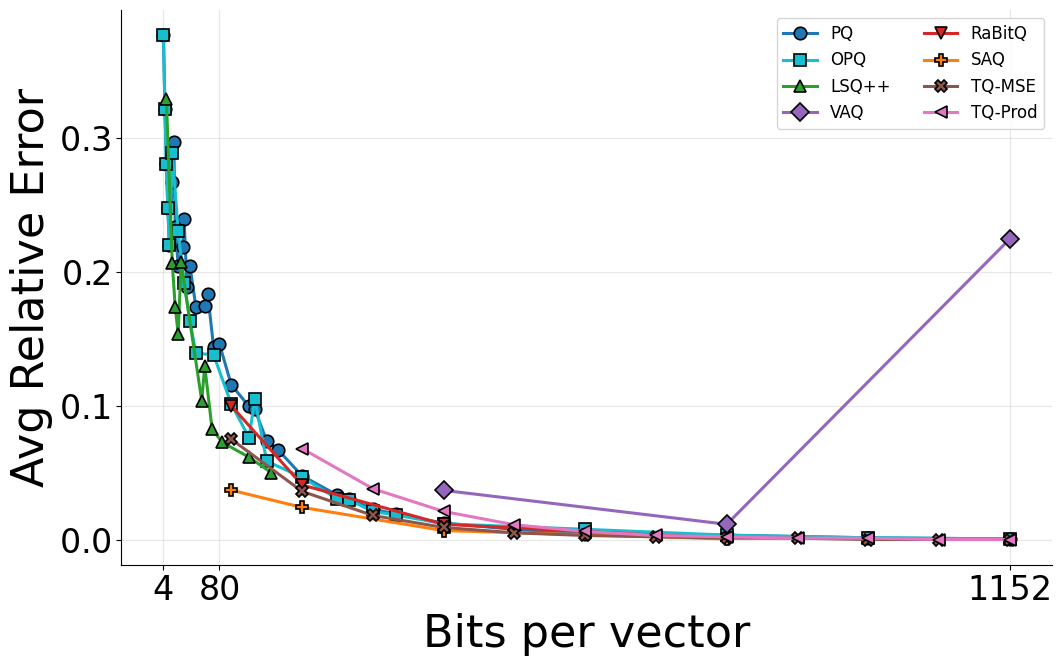

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_bigann.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_bigann.svg


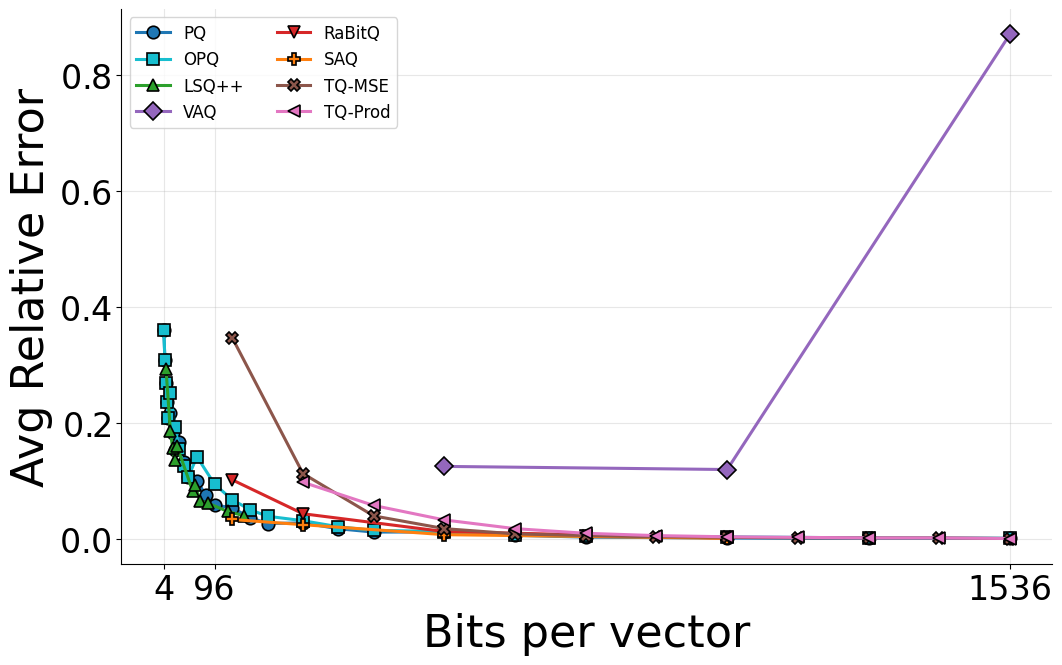

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_gist.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_gist.svg


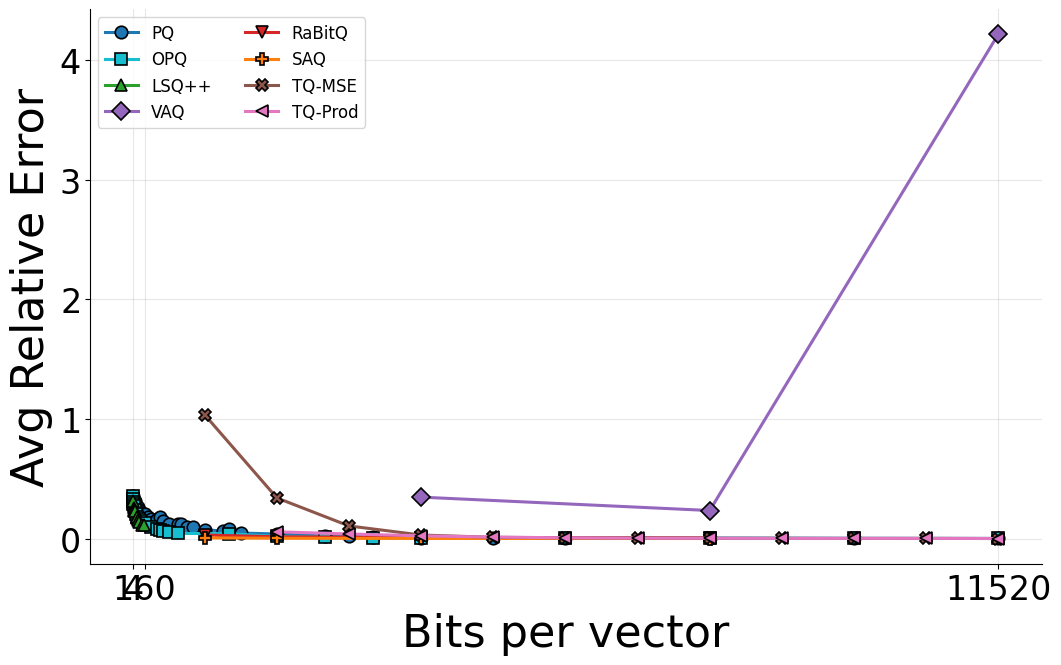

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_msmarco.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_msmarco.svg


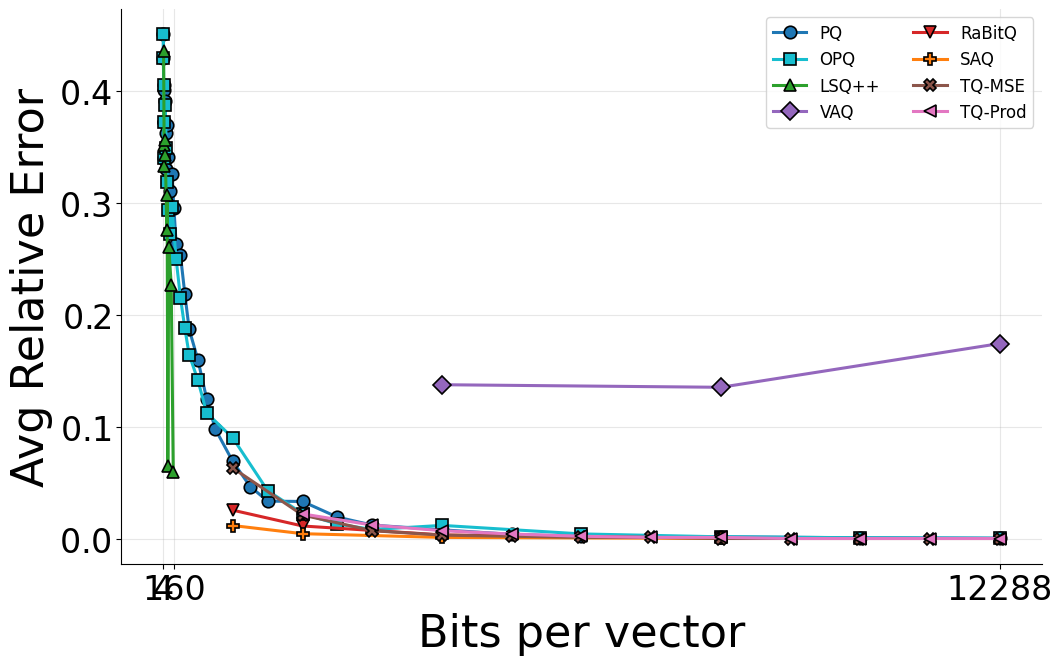

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_openai.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_avg_relerr_vs_bits_per_vector_openai.svg


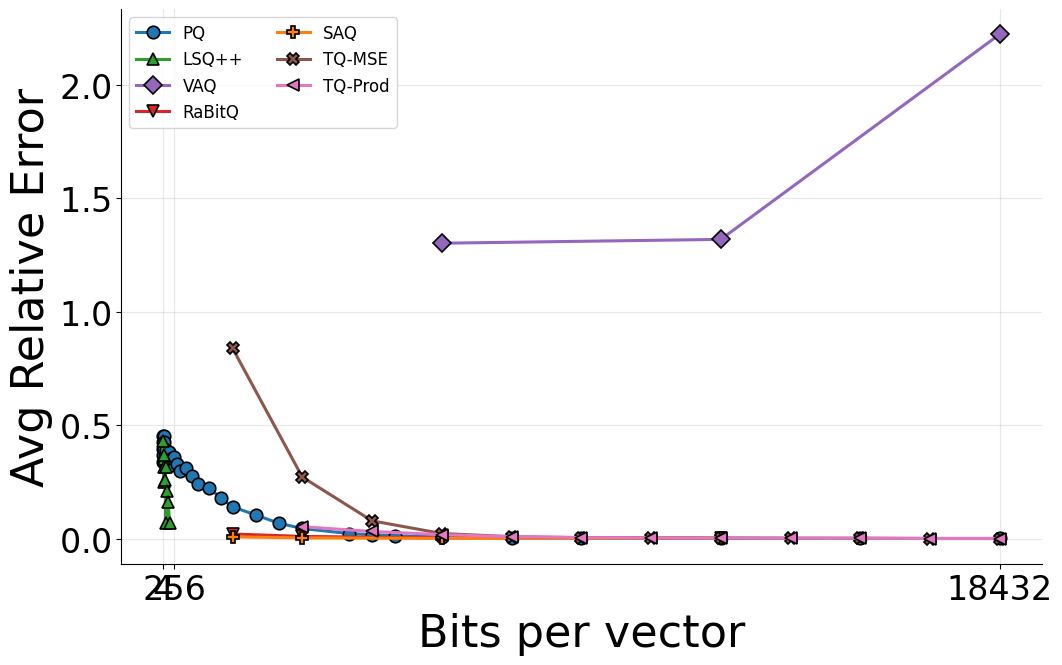

In [5]:
plot_metric_by_dataset(
    plot_df,
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    output_stem="method_comparison_avg_relerr_vs_bits_per_vector",
)


## ADC Time vs Bits per Vector

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_deep.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_deep.svg


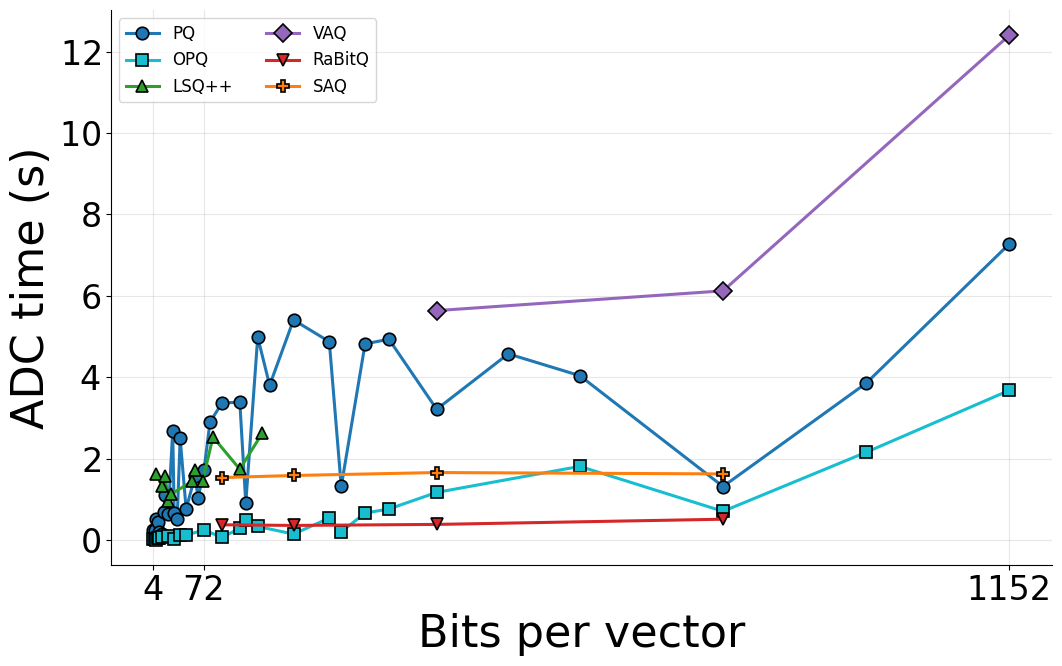

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_bigann.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_bigann.svg


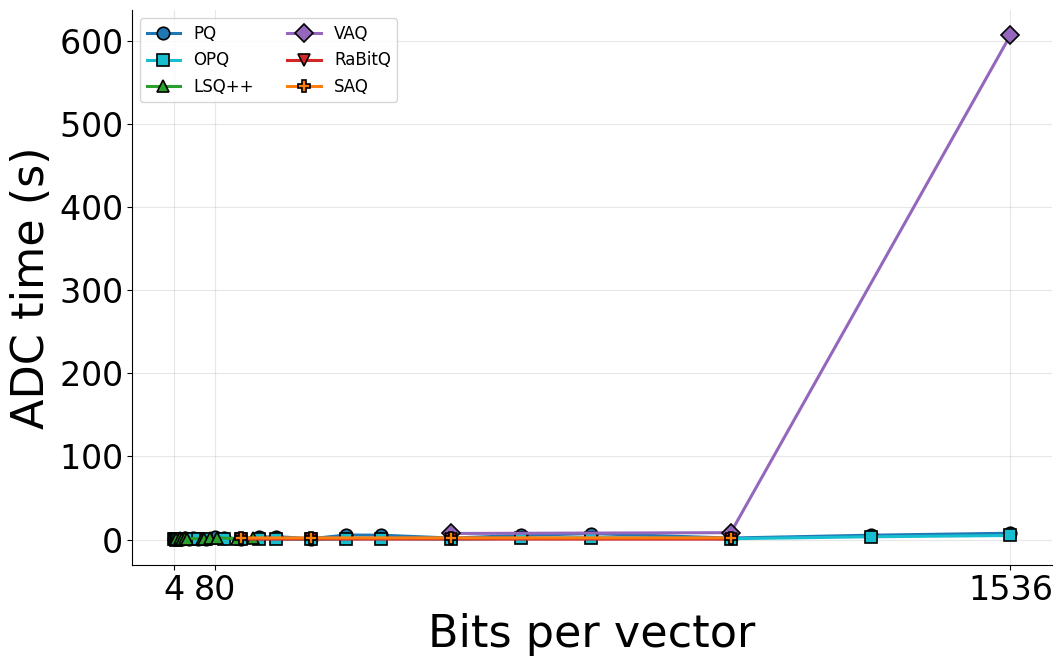

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_gist.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_gist.svg


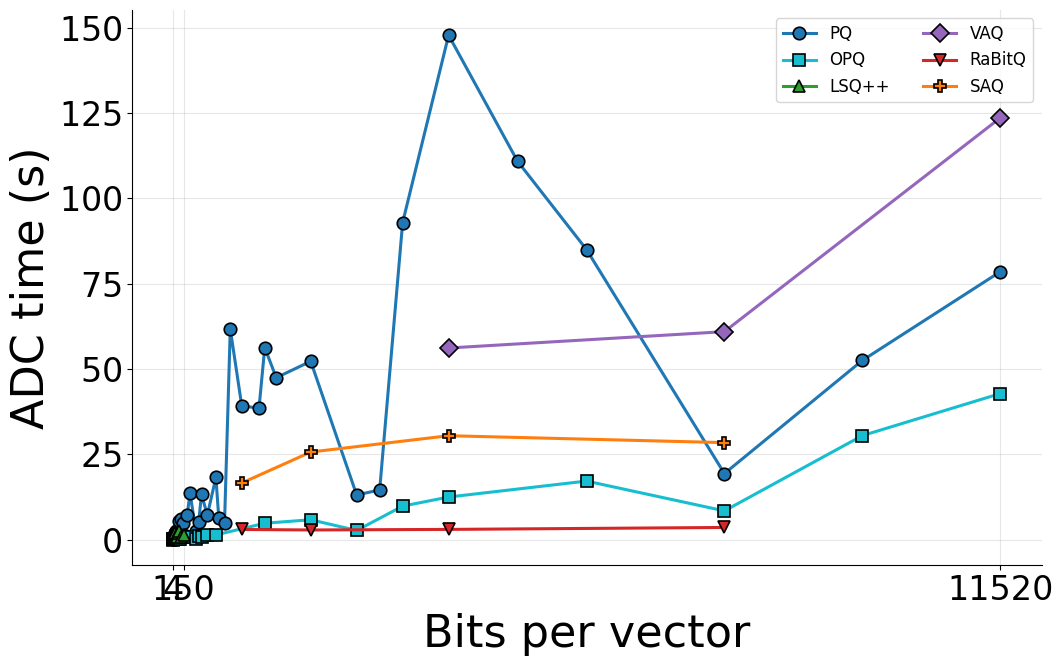

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_msmarco.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_msmarco.svg


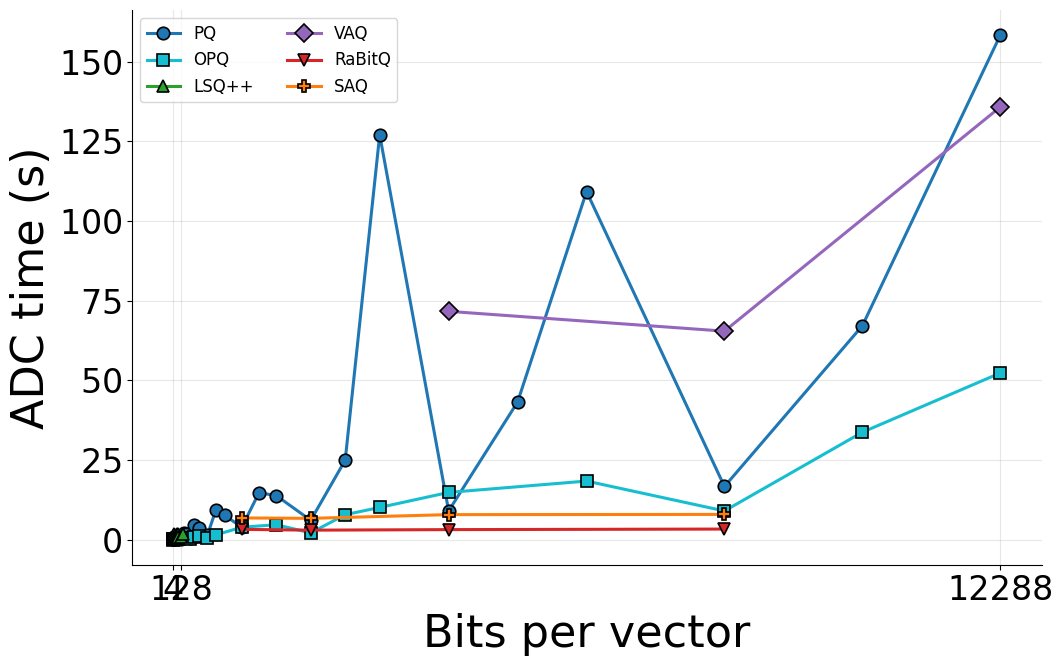

Saved /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_openai.pdf and /data/cpanourg/2-hdvc/results/method_comparison_bpv/figures/method_comparison_adc_time_vs_bits_per_vector_openai.svg


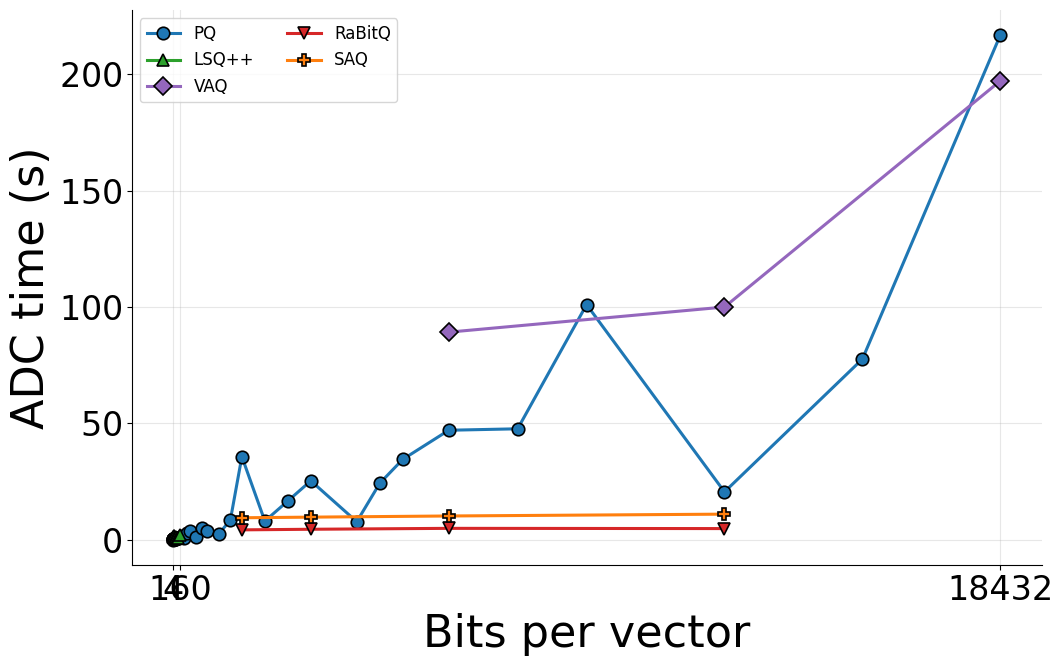

In [6]:
plot_metric_by_dataset(
    plot_df,
    y_col="adc_time_s",
    y_label="ADC time (s)",
    output_stem="method_comparison_adc_time_vs_bits_per_vector",
)


## RaBitQ-Aligned Bits per Vector

These extra plots keep only `bits_per_vector` values that are present for RaBitQ within each dataset. This makes the comparison focus on the same bit budgets as the SAQ-fair RaBitQ runs. The earlier full-range plots above are unchanged.


In [ ]:
def filter_to_rabitq_bpv(df: pd.DataFrame, reference_method: str = "RaBitQ") -> pd.DataFrame:
    frames = []
    for dataset in DATASETS:
        ds = df[df["dataset"].eq(dataset)].copy()
        ref_bpv = sorted(ds[ds["method"].astype(str).eq(reference_method)]["bits_per_vector"].dropna().unique())
        if not ref_bpv:
            print(f"Skipping {dataset}: no {reference_method} bits_per_vector values")
            continue
        aligned = ds[ds["bits_per_vector"].isin(ref_bpv)].copy()
        frames.append(aligned)
        print(f"{dataset}: {reference_method} bpv = {[int(v) for v in ref_bpv]}; kept rows = {len(aligned)}")
    if not frames:
        return df.iloc[0:0].copy()
    return pd.concat(frames, ignore_index=True)


rabitq_aligned_df = filter_to_rabitq_bpv(plot_df)
print("Selected RaBitQ-aligned rows by dataset/method:")
display(
    rabitq_aligned_df.groupby(["dataset", "method"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=DATASETS, columns=METHOD_ORDER, fill_value=0)
)


In [ ]:
plot_metric_by_dataset(
    rabitq_aligned_df,
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    output_stem="method_comparison_rabitq_bpv_avg_relerr_vs_bits_per_vector",
)

plot_metric_by_dataset(
    rabitq_aligned_df,
    y_col="adc_time_s",
    y_label="ADC time (s)",
    output_stem="method_comparison_rabitq_bpv_adc_time_vs_bits_per_vector",
)
